# Pangolin Objective 3

This notebook has been cleaned so that each step appears only once and the downstream variables are created consistently.

Workflow:
1. Import the three KDE intensity rasters.
2. Compute and export the difference rasters: `KDE2 - KDE1` and `KDE3 - KDE2`.
3. Extract hotspot and coldspot centroids from the difference rasters.
4. Construct standard-length coldspot-to-hotspot vectors.
5. Visualize vectors with a colored interior and a black outline.


Stage I raster shape: (350, 325) pixel size: (1995.1644010762805, 1995.764185346765)
Stage II raster shape: (350, 325) pixel size: (1995.1644010762805, 1995.764185346765)
Stage III raster shape: (350, 325) pixel size: (1995.1644010762805, 1995.764185346765)


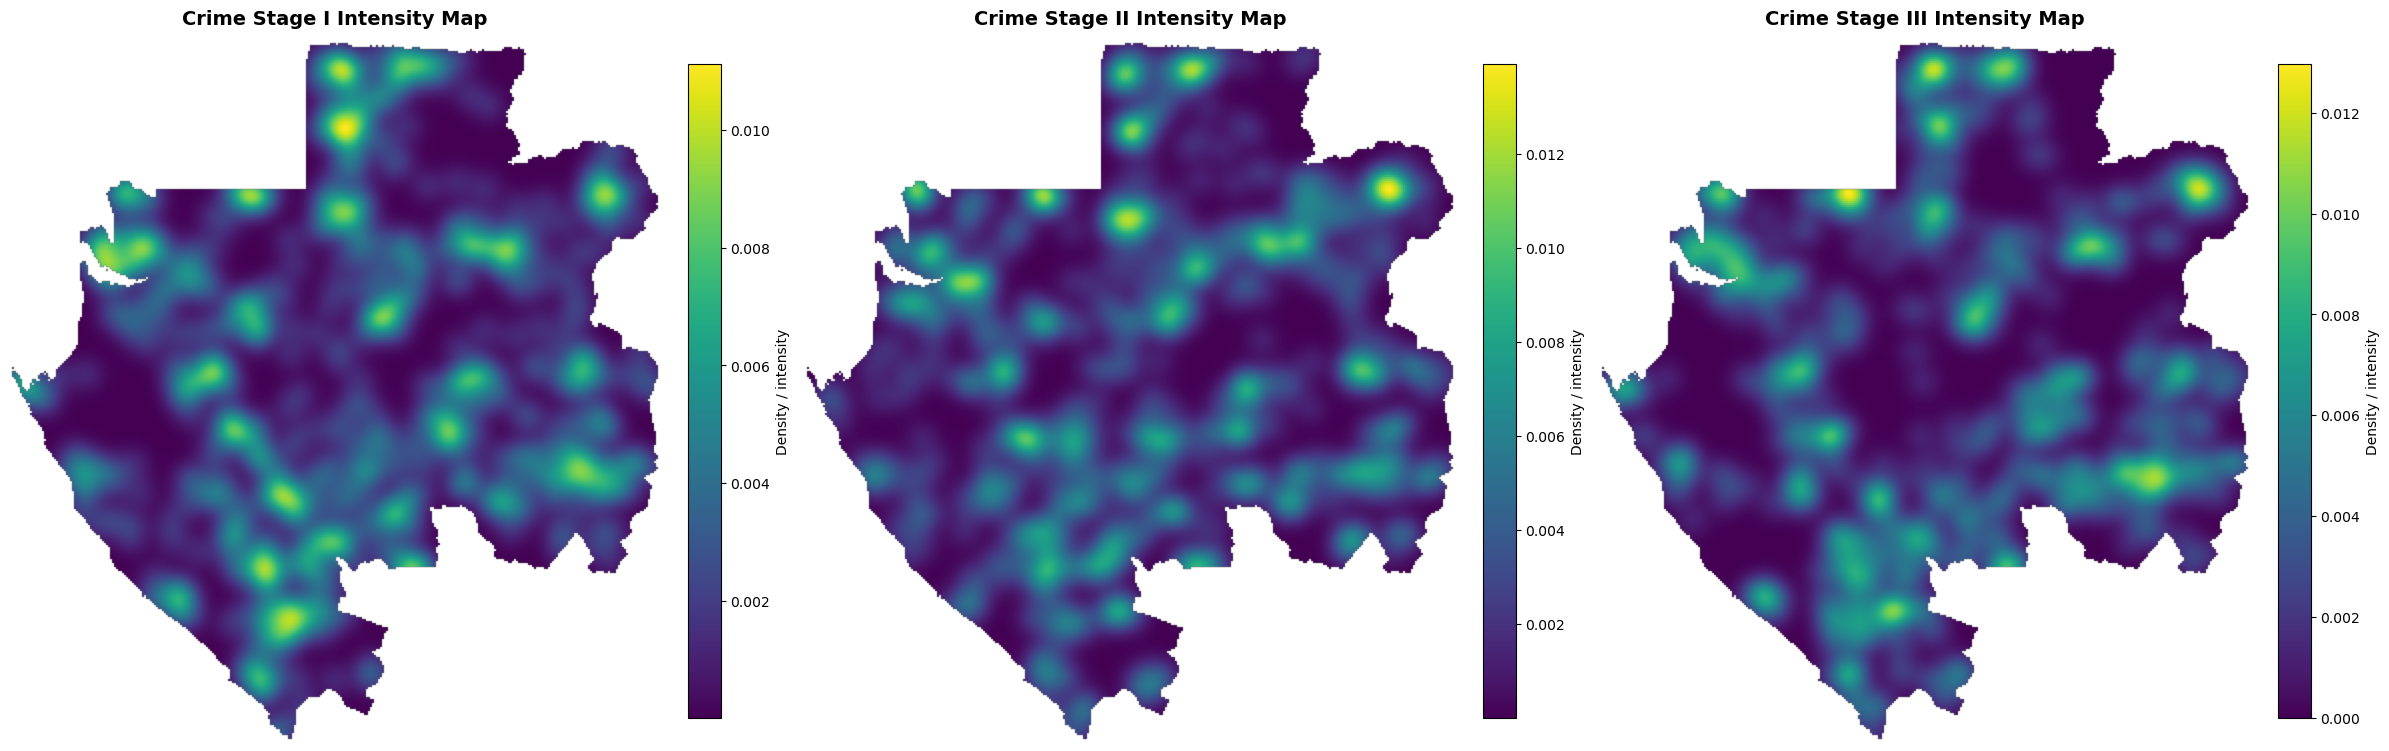

In [10]:

# ============================================================
# 1. IMPORT DATASETS AND PLOT KDE INTENSITY MAPS
# ============================================================

import os
from pathlib import Path

import numpy as np
import geopandas as gpd
import rasterio
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm

from skimage.feature import peak_local_max
from scipy.spatial import cKDTree
from shapely.geometry import Point, LineString
from matplotlib.lines import Line2D
from matplotlib.colors import LinearSegmentedColormap


# ------------------------------------------------------------
# USER PATHS
# ------------------------------------------------------------
input_dir = Path(
    r"C:\Users\eldayit\OneDrive - University of Maryland\Desktop\All files\Ventures\Pangolins_Gabon\Input\Objective_3"
)

output_dir = Path(
    r"C:\Users\eldayit\OneDrive - University of Maryland\Desktop\All files\Ventures\Pangolins_Gabon\Output\Objective_3"
)

output_dir.mkdir(parents=True, exist_ok=True)


# ------------------------------------------------------------
# PARAMETERS
# ------------------------------------------------------------
CRS = "EPSG:5223"

# Your KDE rasters are assumed to be in EPSG:5223.
# In this CRS, map units are meters.
CELL_SIZE_M = 2000

# Peak extraction parameters.
# threshold = 1.5 means peaks must exceed 1.5 standard deviations of the difference surface.
PEAK_THRESHOLD_STD = 1.5

# min_distance=3 pixels means peaks must be at least 3 raster cells apart.
# If the raster cell size is 2 km, this is approximately 6 km.
PEAK_MIN_DISTANCE_PIXELS = 3

# Vector construction parameters.
N_NEAREST_HOTSPOTS = 3
STANDARD_ARROW_LENGTH = 40000  # meters

# Vector styling.
BLACK_OUTLINE_LW = 6.0
COLOR_ARROW_LW = 3.0
BLACK_ARROWHEAD_SIZE = 22
COLOR_ARROWHEAD_SIZE = 16


# ------------------------------------------------------------
# RASTER READER
# ------------------------------------------------------------
def read_metric_raster(file_path):
    """
    Read a single-band EPSG:5223 raster.

    Returns
    -------
    matrix : np.ndarray
        Raster values as float array.
    transform : affine.Affine
        Raster transform used to convert row/column indices to map coordinates.
    extent : list
        [xmin, xmax, ymin, ymax] for matplotlib imshow.
    pixel_width, pixel_height : float
        Pixel size in map units.
    """
    with rasterio.open(file_path) as src:
        matrix = src.read(1).astype(float)
        bounds = src.bounds
        nodata_val = src.nodata
        pixel_width, pixel_height = src.res
        transform = src.transform

        if nodata_val is not None:
            matrix[matrix == nodata_val] = np.nan

        extent = [bounds.left, bounds.right, bounds.bottom, bounds.top]

    return matrix, transform, extent, pixel_width, pixel_height


def assert_same_grid(reference_matrix, reference_transform, other_matrix, other_transform, name):
    """
    Stop early if rasters do not share the same shape and transform.
    Difference maps require aligned rasters.
    """
    if reference_matrix.shape != other_matrix.shape:
        raise ValueError(
            f"{name} has shape {other_matrix.shape}, but Stage I has shape {reference_matrix.shape}. "
            "The rasters must be aligned before subtraction."
        )

    if reference_transform != other_transform:
        print(
            f"Warning: {name} has a different raster transform from Stage I. "
            "If this is not intentional, align the rasters before subtraction."
        )


# ------------------------------------------------------------
# LOAD KDE RASTERS
# ------------------------------------------------------------
im1, trans1, ext1, pw1, ph1 = read_metric_raster(output_dir / "kde_stage_1.tif")
im2, trans2, ext2, pw2, ph2 = read_metric_raster(output_dir / "kde_stage_2.tif")
im3, trans3, ext3, pw3, ph3 = read_metric_raster(output_dir / "kde_stage_3.tif")

assert_same_grid(im1, trans1, im2, trans2, "Stage II raster")
assert_same_grid(im1, trans1, im3, trans3, "Stage III raster")

print("Stage I raster shape:", im1.shape, "pixel size:", (pw1, ph1))
print("Stage II raster shape:", im2.shape, "pixel size:", (pw2, ph2))
print("Stage III raster shape:", im3.shape, "pixel size:", (pw3, ph3))


# ------------------------------------------------------------
# PLOT INTENSITY MAPS
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(24, 8))

stage_maps = [
    (axes[0], im1, ext1, "Crime Stage I Intensity Map"),
    (axes[1], im2, ext2, "Crime Stage II Intensity Map"),
    (axes[2], im3, ext3, "Crime Stage III Intensity Map")
]

for ax, matrix, extent, title in stage_maps:

    im_show = ax.imshow(
        matrix,
        extent=extent,
        cmap="viridis"
    )

    # This keeps the same visual orientation used in your previous validated plots.
    ax.invert_yaxis()

    ax.set_title(title, fontsize=14, fontweight="bold", pad=12)
    ax.set_aspect("equal")
    ax.axis("off")

    plt.colorbar(
        im_show,
        ax=ax,
        label="Density / intensity",
        fraction=0.046,
        pad=0.04
    )

plt.tight_layout()
plt.show()


## What this block does

The first code block imports the required libraries, defines input/output folders, sets the CRS and vector parameters, reads the three KDE rasters, checks whether the rasters are aligned, and plots the three original KDE intensity maps. The shape/transform check is important because `KDE2 - KDE1` and `KDE3 - KDE2` are valid only when the rasters have the same grid.

C:\Users\eldayit\AppData\Local\Temp\ipykernel_22452\1368400455.py:64: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


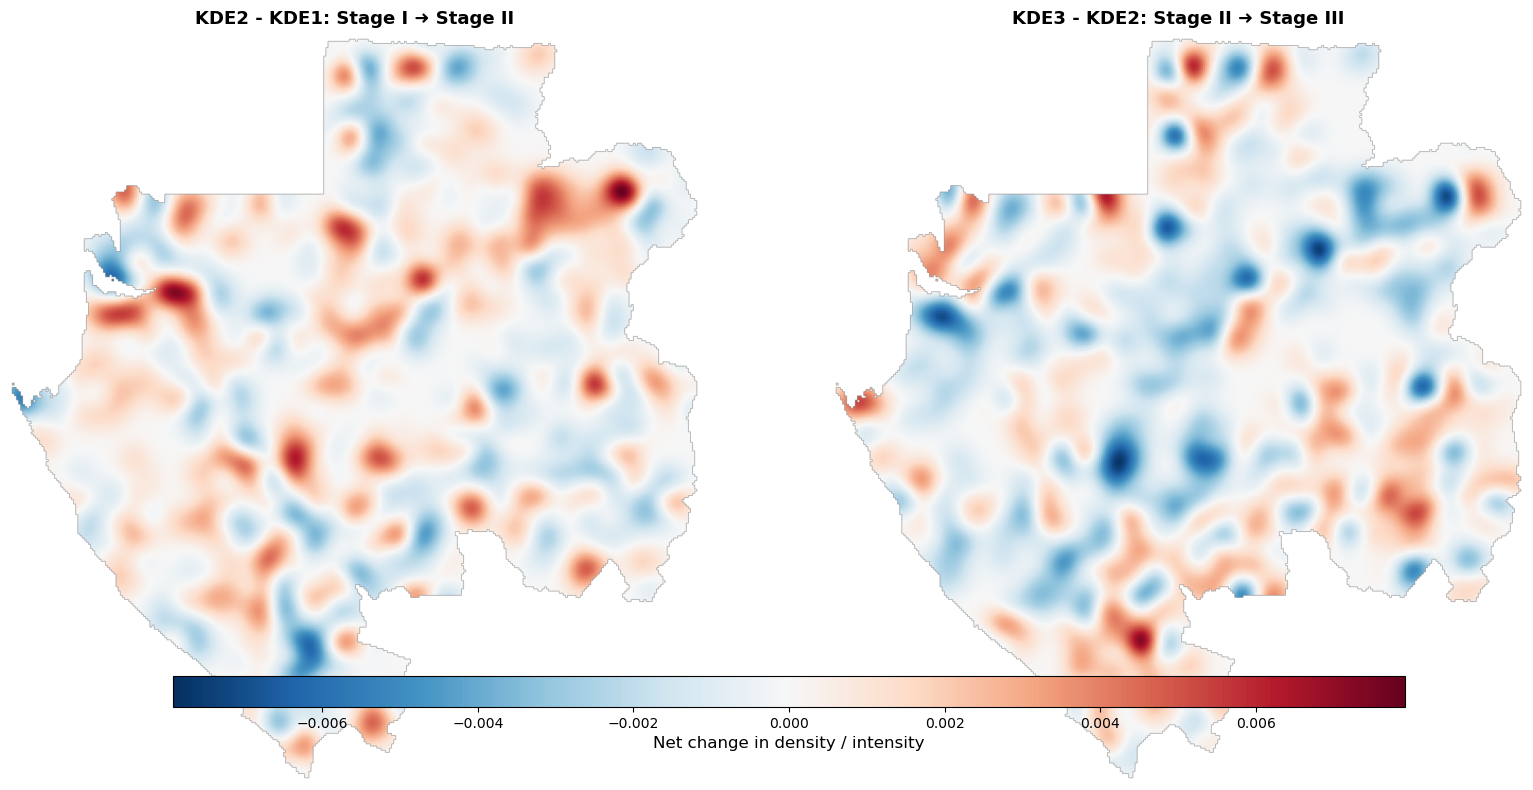

Exported: C:\Users\eldayit\OneDrive - University of Maryland\Desktop\All files\Ventures\Pangolins_Gabon\Output\Objective_3\KDE2_minus_KDE1.tif
Exported: C:\Users\eldayit\OneDrive - University of Maryland\Desktop\All files\Ventures\Pangolins_Gabon\Output\Objective_3\KDE3_minus_KDE2.tif


In [11]:

# ============================================================
# 2. COMPUTE AND EXPORT DIFFERENCE SURFACES
# ============================================================

# Difference surfaces:
# Positive diff_2_1 means Stage II density is higher than Stage I.
# Negative diff_2_1 means Stage I density is higher than Stage II.
diff_2_1 = im2 - im1

# Positive diff_3_2 means Stage III density is higher than Stage II.
# Negative diff_3_2 means Stage II density is higher than Stage III.
diff_3_2 = im3 - im2


# ------------------------------------------------------------
# COMMON COLOR SCALE FOR BOTH DIFFERENCE MAPS
# ------------------------------------------------------------
global_max = np.nanmax([
    np.nanmax(np.abs(diff_2_1)),
    np.nanmax(np.abs(diff_3_2))
])


# ------------------------------------------------------------
# PLOT DIFFERENCE MAPS
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

diff_panels = [
    (axes[0], diff_2_1, ext1, "KDE2 - KDE1: Stage I ➜ Stage II"),
    (axes[1], diff_3_2, ext3, "KDE3 - KDE2: Stage II ➜ Stage III")
]

for ax, diff_matrix, extent, title in diff_panels:

    im_diff = ax.imshow(
        diff_matrix,
        extent=extent,
        cmap="RdBu_r",
        vmin=-global_max,
        vmax=global_max
    )

    ax.invert_yaxis()

    ax.set_title(title, fontsize=13, fontweight="bold", pad=10)
    ax.set_aspect("equal")
    ax.axis("off")


cbar = fig.colorbar(
    im_diff,
    ax=axes,
    orientation="horizontal",
    location="bottom",
    fraction=0.05,
    pad=0.08,
    aspect=40
)

cbar.set_label("Net change in density / intensity", fontsize=12)
cbar.ax.tick_params(labelsize=10)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# EXPORT DIFFERENCE RASTERS
# ------------------------------------------------------------
def export_difference_raster(output_path, matrix, transform):
    """
    Export a difference matrix as an EPSG:5223 GeoTIFF.
    """
    with rasterio.open(
        output_path,
        "w",
        driver="GTiff",
        height=matrix.shape[0],
        width=matrix.shape[1],
        count=1,
        dtype="float32",
        crs=CRS,
        transform=transform,
        nodata=np.nan
    ) as dst:
        dst.write(matrix.astype("float32"), 1)

    print(f"Exported: {output_path}")


export_difference_raster(
    output_dir / "KDE2_minus_KDE1.tif",
    diff_2_1,
    trans1
)

export_difference_raster(
    output_dir / "KDE3_minus_KDE2.tif",
    diff_3_2,
    trans3
)


## What this block does

This block computes the two transition surfaces. `diff_2_1 = im2 - im1` shows where Stage II is higher or lower than Stage I. `diff_3_2 = im3 - im2` does the same for Stage III relative to Stage II. The duplicate difference-plot cells from the original notebook were merged into this one corrected block, and the undefined `output_figure` print statement was removed.

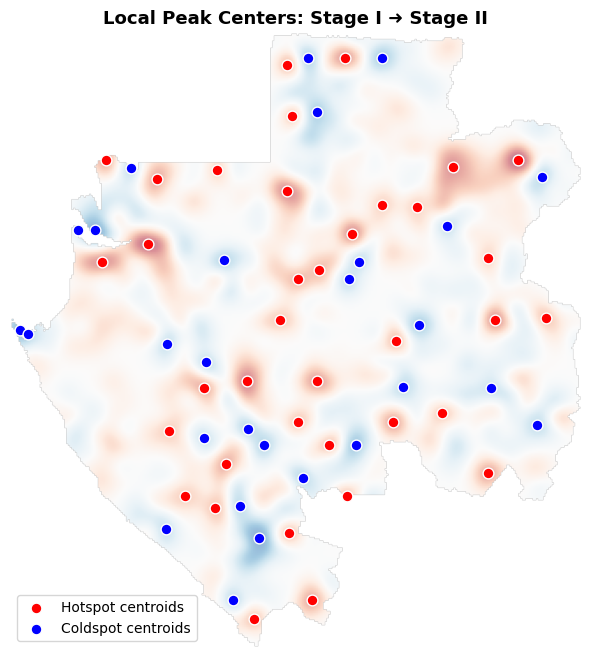

Stage I ➜ Stage II: 37 hot peaks, 28 cold peaks


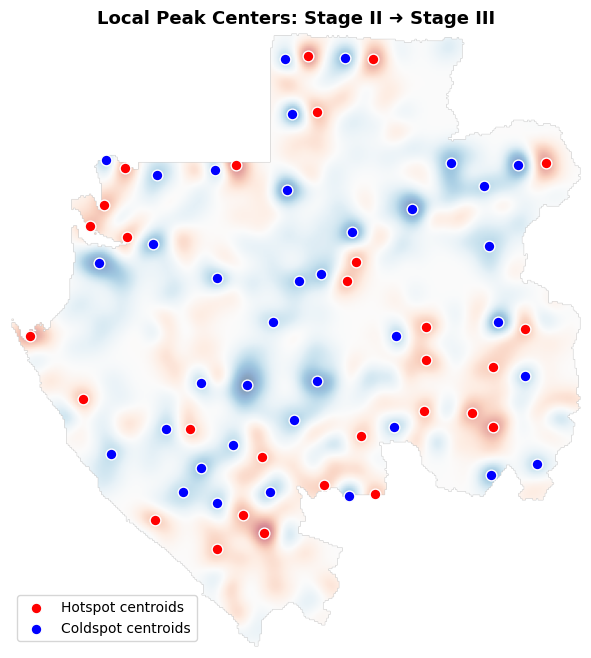

Stage II ➜ Stage III: 29 hot peaks, 37 cold peaks


Exported hotspot and coldspot centroid GeoPackages.


In [12]:

# ============================================================
# 3. EXTRACT HOTSPOT AND COLDSPOT CENTROIDS
# ============================================================

def extract_local_peak_centroids(
    diff_matrix,
    extent,
    transform,
    title,
    threshold_std=1.5,
    min_distance=3,
    crs=CRS,
    plot=True
):
    """
    Extract local positive peaks and local negative peaks from a difference surface.

    Hotspots are positive local maxima in the difference surface.
    Coldspots are negative local minima, detected as local maxima of -difference.

    Returns
    -------
    hot_gdf : GeoDataFrame
        Point centroids where the difference surface is locally high.
    cold_gdf : GeoDataFrame
        Point centroids where the difference surface is locally low.
    """

    std = np.nanstd(diff_matrix)

    hot_surface = np.where(np.isnan(diff_matrix), -np.inf, diff_matrix)
    cold_surface = np.where(np.isnan(diff_matrix), -np.inf, -diff_matrix)

    hot_peaks = peak_local_max(
        hot_surface,
        min_distance=min_distance,
        threshold_abs=threshold_std * std,
        exclude_border=False
    )

    cold_peaks = peak_local_max(
        cold_surface,
        min_distance=min_distance,
        threshold_abs=threshold_std * std,
        exclude_border=False
    )

    def peaks_to_gdf(peaks, kind):
        records = []

        for row, col in peaks:
            x, y = rasterio.transform.xy(transform, row, col, offset="center")
            density_value = diff_matrix[row, col]

            records.append({
                "row": int(row),
                "col": int(col),
                "peak_type": kind,
                "density_value": float(density_value),
                "geometry": Point(x, y)
            })

        return gpd.GeoDataFrame(records, crs=crs)

    hot_gdf = peaks_to_gdf(hot_peaks, "hot")
    cold_gdf = peaks_to_gdf(cold_peaks, "cold")

    if plot:
        fig, ax = plt.subplots(figsize=(10, 8))

        max_val = np.nanmax(np.abs(diff_matrix))

        ax.imshow(
            diff_matrix,
            extent=extent,
            cmap="RdBu_r",
            vmin=-max_val,
            vmax=max_val,
            alpha=0.5
        )

        ax.invert_yaxis()

        if len(hot_gdf) > 0:
            hot_gdf.plot(
                ax=ax,
                color="red",
                markersize=60,
                edgecolor="white",
                label="Hotspot centroids"
            )

        if len(cold_gdf) > 0:
            cold_gdf.plot(
                ax=ax,
                color="blue",
                markersize=60,
                edgecolor="white",
                label="Coldspot centroids"
            )

        ax.set_title(f"Local Peak Centers: {title}", fontsize=13, fontweight="bold")
        ax.set_aspect("equal")
        ax.axis("off")
        ax.legend(loc="lower left")

        plt.show()

    print(f"{title}: {len(hot_gdf)} hot peaks, {len(cold_gdf)} cold peaks")

    return hot_gdf, cold_gdf


# ------------------------------------------------------------
# CREATE THE GEODataFrames NEEDED BY THE VECTOR CODE
# ------------------------------------------------------------
hot_21, cold_21 = extract_local_peak_centroids(
    diff_2_1,
    ext1,
    trans1,
    "Stage I ➜ Stage II",
    threshold_std=PEAK_THRESHOLD_STD,
    min_distance=PEAK_MIN_DISTANCE_PIXELS
)

hot_32, cold_32 = extract_local_peak_centroids(
    diff_3_2,
    ext3,
    trans3,
    "Stage II ➜ Stage III",
    threshold_std=PEAK_THRESHOLD_STD,
    min_distance=PEAK_MIN_DISTANCE_PIXELS
)


# ------------------------------------------------------------
# OPTIONAL: EXPORT PEAK CENTROIDS
# ------------------------------------------------------------
hot_21.to_file(output_dir / "hotspots_stage_2_minus_stage_1.gpkg", driver="GPKG")
cold_21.to_file(output_dir / "coldspots_stage_2_minus_stage_1.gpkg", driver="GPKG")

hot_32.to_file(output_dir / "hotspots_stage_3_minus_stage_2.gpkg", driver="GPKG")
cold_32.to_file(output_dir / "coldspots_stage_3_minus_stage_2.gpkg", driver="GPKG")

print("Exported hotspot and coldspot centroid GeoPackages.")


## What this block does

The original centroid block only plotted the hot and cold peak locations; it did not save them into variables for later use. This corrected block creates the four GeoDataFrames that the vector code needs: `hot_21`, `cold_21`, `hot_32`, and `cold_32`. Each centroid includes its raster row, column, peak type, and `density_value` from the difference surface.

In [13]:

# ============================================================
# 4. STANDARD-LENGTH VECTOR GRADIENT FIELD
# Cold spots ➜ nearest hotspots
# Length = constant
# Color  = raw gradient magnitude
# Vectors = colored arrows with black outline
# ============================================================

def construct_standard_length_gradient_vectors(cold_gdf, hot_gdf, n_nearest=3):
    """
    Construct vectors from each coldspot centroid toward its nearest hotspot centroids.

    The hotspot determines the direction.
    The arrow length is fixed.
    The arrow color is based on abs((hot_density - cold_density) / distance).
    """

    if len(cold_gdf) == 0 or len(hot_gdf) == 0:
        print("No vectors created because either cold_gdf or hot_gdf is empty.")
        return gpd.GeoDataFrame(columns=[
            "cold_id", "hot_id", "distance_m", "cold_density", "hot_density",
            "density_difference", "gradient_magnitude", "abs_gradient",
            "standard_arrow_length_m", "geometry"
        ], crs=CRS)

    hot_xy = np.column_stack([hot_gdf.geometry.x, hot_gdf.geometry.y])
    cold_xy = np.column_stack([cold_gdf.geometry.x, cold_gdf.geometry.y])

    tree = cKDTree(hot_xy)
    records = []

    for cold_idx, cold_point in enumerate(cold_xy):

        distances, hot_indices = tree.query(
            cold_point,
            k=min(n_nearest, len(hot_gdf))
        )

        distances = np.atleast_1d(distances)
        hot_indices = np.atleast_1d(hot_indices)

        cold_density = cold_gdf.iloc[cold_idx]["density_value"]

        for dist, hot_idx in zip(distances, hot_indices):

            if dist == 0:
                continue

            hot_point = hot_xy[hot_idx]
            hot_density = hot_gdf.iloc[hot_idx]["density_value"]

            density_difference = hot_density - cold_density
            gradient_magnitude = density_difference / dist
            abs_gradient = abs(gradient_magnitude)

            direction = (hot_point - cold_point) / dist
            end_point = cold_point + direction * STANDARD_ARROW_LENGTH

            line = LineString([
                (cold_point[0], cold_point[1]),
                (end_point[0], end_point[1])
            ])

            records.append({
                "cold_id": cold_idx,
                "hot_id": int(hot_idx),
                "distance_m": float(dist),
                "cold_density": float(cold_density),
                "hot_density": float(hot_density),
                "density_difference": float(density_difference),
                "gradient_magnitude": float(gradient_magnitude),
                "abs_gradient": float(abs_gradient),
                "standard_arrow_length_m": STANDARD_ARROW_LENGTH,
                "geometry": line
            })

    vectors_gdf = gpd.GeoDataFrame(records, crs=CRS)

    print("Number of vectors:", len(vectors_gdf))
    print("Raw gradient minimum:", vectors_gdf["abs_gradient"].min())
    print("Raw gradient maximum:", vectors_gdf["abs_gradient"].max())
    print("Standard arrow length:", STANDARD_ARROW_LENGTH, "meters")

    return vectors_gdf


def draw_outlined_arrow(ax, start, end, arrow_color):
    """
    Draw one arrow twice:
    1. thick black arrow underneath
    2. thinner colored arrow on top
    """
    ax.annotate(
        "",
        xy=end,
        xytext=start,
        arrowprops=dict(
            arrowstyle="->",
            color="black",
            lw=BLACK_OUTLINE_LW,
            mutation_scale=BLACK_ARROWHEAD_SIZE,
            shrinkA=0,
            shrinkB=0
        ),
        zorder=5
    )

    ax.annotate(
        "",
        xy=end,
        xytext=start,
        arrowprops=dict(
            arrowstyle="->",
            color=arrow_color,
            lw=COLOR_ARROW_LW,
            mutation_scale=COLOR_ARROWHEAD_SIZE,
            shrinkA=0,
            shrinkB=0
        ),
        zorder=6
    )


# ------------------------------------------------------------
# CREATE VECTORS
# ------------------------------------------------------------
vectors_21_standard = construct_standard_length_gradient_vectors(
    cold_21,
    hot_21,
    n_nearest=N_NEAREST_HOTSPOTS
)

vectors_32_standard = construct_standard_length_gradient_vectors(
    cold_32,
    hot_32,
    n_nearest=N_NEAREST_HOTSPOTS
)

vectors_21_standard.to_file(output_dir / "standard_vectors_stage_1_to_stage_2.gpkg", driver="GPKG")
vectors_32_standard.to_file(output_dir / "standard_vectors_stage_2_to_stage_3.gpkg", driver="GPKG")

print("Exported vector GeoPackages.")


Number of vectors: 84
Raw gradient minimum: 3.72365353947476e-08
Raw gradient maximum: 3.2408477774216825e-07
Standard arrow length: 40000 meters
Number of vectors: 111
Raw gradient minimum: 3.719858485041262e-08
Raw gradient maximum: 3.842841107047957e-07
Standard arrow length: 40000 meters


Exported vector GeoPackages.


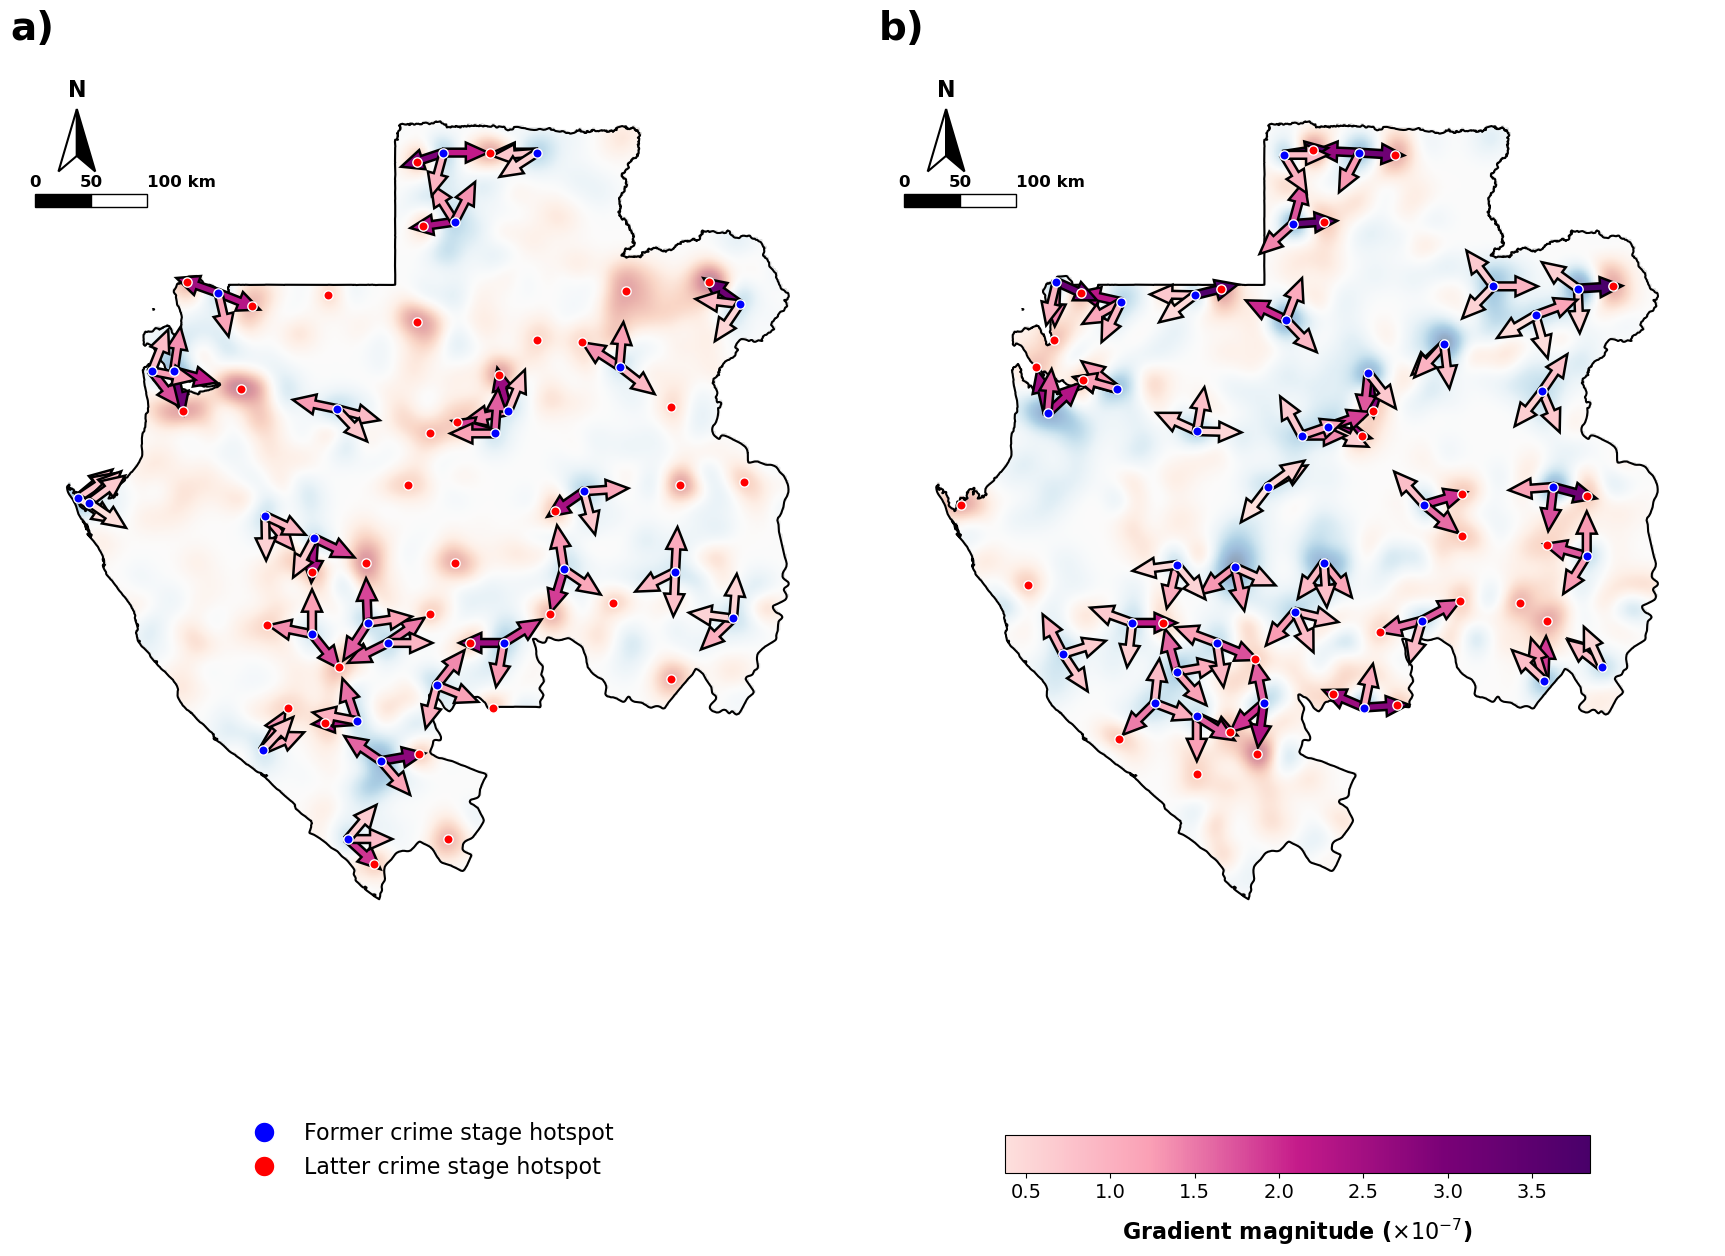

Combined figure saved to: C:\Users\eldayit\OneDrive - University of Maryland\Desktop\All files\Ventures\Pangolins_Gabon\Output\Standard_Length_Gradient_Vectors_Combined.png


In [18]:
from pathlib import Path
import geopandas as gpd
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
from matplotlib.cm import ScalarMappable
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.lines import Line2D
from matplotlib.patches import FancyArrow, Polygon, Rectangle

# ------------------------------------------------------------
# 1. PATHS AND DATA LOADING
# ------------------------------------------------------------
output_dir = Path(
    r"C:\Users\eldayit\OneDrive - University of Maryland\Desktop\All files\Ventures\Pangolins_Gabon\Output"
)
output_figure = output_dir / "Standard_Length_Gradient_Vectors_Combined.png"

aux_dir = Path(
    r"C:\Users\eldayit\OneDrive - University of Maryland\Desktop\All files\Ventures\Pangolins_Gabon\AuxiliaryDatasets"
)

gabon_boundary_path = aux_dir / "Gabon_country_boundary_UNOCHA_EPSG5223.gpkg"
gabon_boundary = gpd.read_file(gabon_boundary_path)

# Ensure boundary CRS matches vector layer CRS
if gabon_boundary.crs != vectors_21_standard.crs:
    gabon_boundary = gabon_boundary.to_crs(vectors_21_standard.crs)

# ------------------------------------------------------------
# 2. COLORMAP & NORMALIZATION (MAGENTA GRADIENT)
# ------------------------------------------------------------
all_magnitudes = np.concatenate([
    vectors_21_standard["abs_gradient"].values,
    vectors_32_standard["abs_gradient"].values,
])
all_magnitudes = all_magnitudes[np.isfinite(all_magnitudes)]

if len(all_magnitudes) == 0:
    raise ValueError(
        "No vector magnitudes found. Check hotspot/coldspot extraction."
    )

norm = mcolors.Normalize(
    vmin=np.nanmin(all_magnitudes), vmax=np.nanmax(all_magnitudes)
)

# Magenta sequential color palette
cmap = LinearSegmentedColormap.from_list(
    "custom_magenta", ["#fde0dd", "#fa9fb5", "#c51b8a", "#7a0177", "#49006a"]
)


# ------------------------------------------------------------
# 3. HELPER FUNCTIONS
# ------------------------------------------------------------
def draw_outlined_arrow(
    ax,
    start,
    end,
    arrow_color,
    width=7000,
    head_width=18000,
    head_length=20000,
    zorder=6,
):
    """Draws a unified 2D block polygon arrow filled with color and outlined in black."""
    dx = end[0] - start[0]
    dy = end[1] - start[1]

    arrow = FancyArrow(
        x=start[0],
        y=start[1],
        dx=dx,
        dy=dy,
        width=width,
        head_width=head_width,
        head_length=head_length,
        length_includes_head=True,
        facecolor=arrow_color,
        edgecolor="black",
        linewidth=1.8,
        zorder=zorder,
    )
    ax.add_patch(arrow)


def add_map_elements(ax, xmin, xmax, ymin, ymax):
    """Draws North Arrow and Subdivided Scale Bar anchored to top-left."""
    x_span = xmax - xmin
    y_span = ymax - ymin

    # 1. NORTH ARROW
    na_x = xmin + x_span * 0.08
    na_y = ymax - y_span * 0.12
    arrow_h = y_span * 0.07
    arrow_w = x_span * 0.022

    left_triangle = Polygon(
        [
            [na_x, na_y + arrow_h],
            [na_x - arrow_w, na_y],
            [na_x, na_y + arrow_h * 0.25],
        ],
        facecolor="white",
        edgecolor="black",
        lw=1.5,
        zorder=12,
    )
    right_triangle = Polygon(
        [
            [na_x, na_y + arrow_h],
            [na_x, na_y + arrow_h * 0.25],
            [na_x + arrow_w, na_y],
        ],
        facecolor="black",
        edgecolor="black",
        lw=1.5,
        zorder=12,
    )
    ax.add_patch(left_triangle)
    ax.add_patch(right_triangle)

    ax.text(
        na_x,
        na_y + arrow_h * 1.12,
        "N",
        ha="center",
        va="bottom",
        fontsize=16,
        fontweight="bold",
        zorder=12,
    )

    # 2. SUBDIVIDED SCALE BAR
    sb_total_m = 100000  # 100 km
    sb_seg_m = 50000

    sb_x0 = xmin + x_span * 0.03
    sb_y0 = ymax - y_span * 0.16
    sb_h = y_span * 0.015

    ax.add_patch(
        Rectangle(
            (sb_x0, sb_y0),
            sb_seg_m,
            sb_h,
            facecolor="black",
            edgecolor="black",
            zorder=12,
        )
    )
    ax.add_patch(
        Rectangle(
            (sb_x0 + sb_seg_m, sb_y0),
            sb_seg_m,
            sb_h,
            facecolor="white",
            edgecolor="black",
            zorder=12,
        )
    )

    label_y = sb_y0 + sb_h * 1.3
    ax.text(
        sb_x0,
        label_y,
        "0",
        ha="center",
        va="bottom",
        fontsize=12,
        fontweight="bold",
        zorder=12,
    )
    ax.text(
        sb_x0 + sb_seg_m,
        label_y,
        "50",
        ha="center",
        va="bottom",
        fontsize=12,
        fontweight="bold",
        zorder=12,
    )
    ax.text(
        sb_x0 + sb_total_m,
        label_y,
        "100 km",
        ha="left",
        va="bottom",
        fontsize=12,
        fontweight="bold",
        zorder=12,
    )


# ------------------------------------------------------------
# 4. MAIN LAYOUT SETUP (GRIDSPEC)
# ------------------------------------------------------------
fig = plt.figure(figsize=(22, 16))

# GridSpec: 2 rows for maps (top) and bottom elements (colorbar/legend)
gs = fig.add_gridspec(
    2,
    2,
    height_ratios=[1, 0.15],
    width_ratios=[1, 1],
    wspace=0.04,
    hspace=0.08,
)

ax_map1 = fig.add_subplot(gs[0, 0])
ax_map2 = fig.add_subplot(gs[0, 1])
ax_leg = fig.add_subplot(gs[1, 0])
ax_cbar_container = fig.add_subplot(gs[1, 1])

panels = [
    (ax_map1, diff_2_1, ext1, hot_21, cold_21, vectors_21_standard, "a)"),
    (ax_map2, diff_3_2, ext3, hot_32, cold_32, vectors_32_standard, "b)"),
]

# ------------------------------------------------------------
# 5. RENDER MAP PANELS
# ------------------------------------------------------------
for ax, diff_matrix, raw_extent, hot_gdf, cold_gdf, vectors_gdf, title in panels:

    max_val = np.nanmax(np.abs(diff_matrix))

    xmin = min(raw_extent[0], raw_extent[1])
    xmax = max(raw_extent[0], raw_extent[1])
    ymin = min(raw_extent[2], raw_extent[3])
    ymax = max(raw_extent[2], raw_extent[3])

    corrected_extent = [xmin, xmax, ymin, ymax]

    ax.imshow(
        diff_matrix,
        extent=corrected_extent,
        cmap="RdBu_r",
        vmin=-max_val,
        vmax=max_val,
        alpha=0.45,
        origin="lower",
        zorder=1,
    )

    gabon_boundary.boundary.plot(
        ax=ax, color="black", linewidth=1.5, zorder=5
    )

    if len(hot_gdf) > 0:
        hot_gdf.plot(
            ax=ax,
            color="red",
            markersize=45,
            edgecolor="white",
            zorder=7,
        )

    if len(cold_gdf) > 0:
        cold_gdf.plot(
            ax=ax,
            color="blue",
            markersize=45,
            edgecolor="white",
            zorder=7,
        )

    for _, row in vectors_gdf.iterrows():
        coords = np.array(row.geometry.coords)
        start = coords[0]
        end = coords[-1]
        arrow_color = cmap(norm(row["abs_gradient"]))

        draw_outlined_arrow(
            ax=ax,
            start=start,
            end=end,
            arrow_color=arrow_color,
            width=7000,
            head_width=18000,
            head_length=20000,
            zorder=6,
        )

    ax.set_title(title, fontsize=28, fontweight="bold", loc="left", pad=18)
    ax.set_aspect("equal")

    # Extent padding
    padding_m = 50000
    xmin_pad, xmax_pad = xmin - padding_m, xmax + padding_m
    ymin_pad, ymax_pad = ymin - padding_m, ymax + padding_m

    ax.set_xlim(xmin_pad, xmax_pad)
    ax.set_ylim(ymin_pad, ymax_pad)

    ax.axis("off")
    add_map_elements(ax, xmin_pad, xmax_pad, ymin_pad, ymax_pad)

# ------------------------------------------------------------
# 6. RENDER BOTTOM LEGEND (LEFT BOTTOM)
# ------------------------------------------------------------
ax_leg.axis("off")

legend_elements = [
    Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        markerfacecolor="blue",
        markeredgecolor="white",
        markersize=15,
        label="Former crime stage hotspot",
    ),
    Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        markerfacecolor="red",
        markeredgecolor="white",
        markersize=15,
        label="Latter crime stage hotspot",
    ),
]

ax_leg.legend(
    handles=legend_elements,
    loc="center",
    fontsize=16,
    frameon=True,
    facecolor="white",
    framealpha=1.0,
    edgecolor="none",
)

# ------------------------------------------------------------
# 7. RENDER BOTTOM COLORBAR (RIGHT BOTTOM)
# ------------------------------------------------------------
ax_cbar_container.axis("off")

# Position colorbar explicitly in container bounding box
cbar_ax = ax_cbar_container.inset_axes([0.15, 0.35, 0.7, 0.25])

sm = ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

cbar = fig.colorbar(sm, cax=cbar_ax, orientation="horizontal")

cbar.ax.xaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f"{x * 1e7:.1f}")
)

cbar.ax.tick_params(labelsize=14)
cbar.set_label(
    r"Gradient magnitude ($\times 10^{-7}$)",
    fontsize=16,
    fontweight="bold",
    labelpad=10,
)

# ------------------------------------------------------------
# 8. SAVE & DISPLAY
# ------------------------------------------------------------
fig.savefig(output_figure, dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

print(f"Combined figure saved to: {output_figure}")


Stage I → Stage II
-------------------
 N: 12
NE: 12
 E: 11
SE: 12
 S: 10
SW: 8
 W: 15
NW: 4
TOTAL: 84

Stage II → Stage III
--------------------
 N: 12
NE: 5
 E: 22
SE: 15
 S: 16
SW: 17
 W: 11
NW: 13
TOTAL: 111


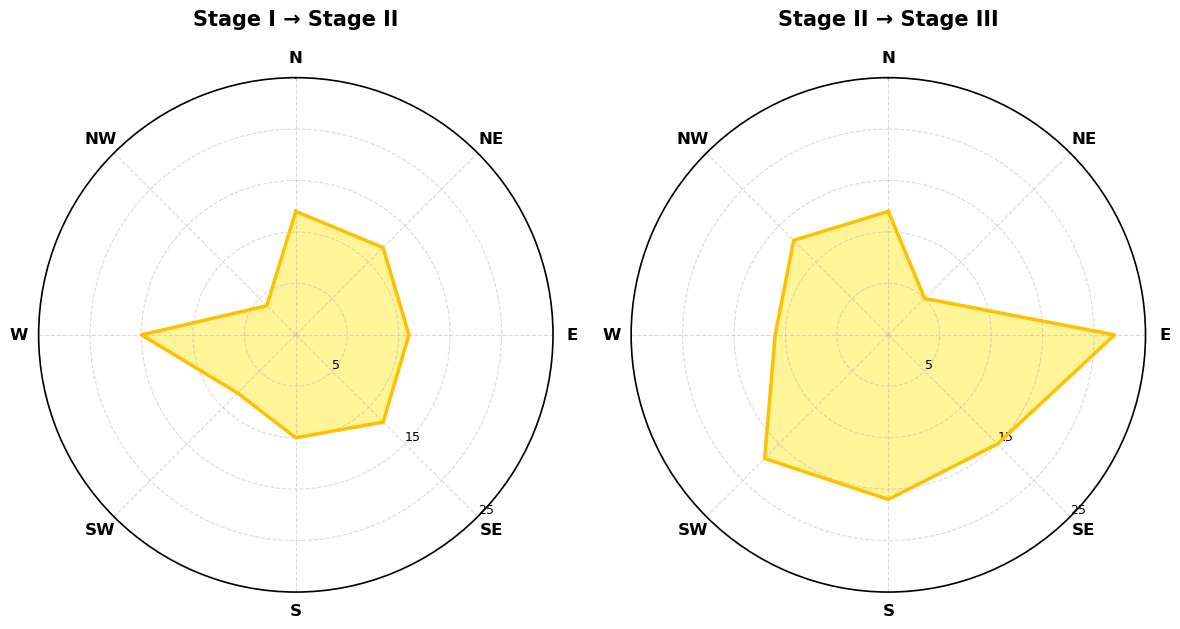

In [28]:
# ============================================================
# SPIDER CHARTS — NUMBER OF VECTORS BY DIRECTION
#
# vectors_21_standard = Stage I → Stage II
# vectors_32_standard = Stage II → Stage III
#
# Spider-chart radius = NUMBER OF VECTORS
# Grid interval = 5 vectors
# Labels shown = 5, 15, 25
# ============================================================

import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 1. COUNT VECTORS IN EACH OF THE 8 DIRECTIONS
# ------------------------------------------------------------

def count_vectors_by_direction(vectors_gdf):

    directions = [
        "N", "NE", "E", "SE",
        "S", "SW", "W", "NW"
    ]

    counts = {
        direction: 0
        for direction in directions
    }

    for _, row in vectors_gdf.iterrows():

        # Get vector start and end coordinates
        coords = np.array(row.geometry.coords)

        x1, y1 = coords[0]
        x2, y2 = coords[-1]

        dx = x2 - x1
        dy = y2 - y1

        # ----------------------------------------------------
        # Calculate direction angle
        #
        # 0°   = East
        # 45°  = Northeast
        # 90°  = North
        # 135° = Northwest
        # 180° = West
        # 225° = Southwest
        # 270° = South
        # 315° = Southeast
        # ----------------------------------------------------

        angle = np.degrees(
            np.arctan2(dy, dx)
        )

        angle = (angle + 360) % 360

        # ----------------------------------------------------
        # CLASSIFY INTO 8 DIRECTIONS
        # ----------------------------------------------------

        if angle >= 337.5 or angle < 22.5:
            direction = "E"

        elif 22.5 <= angle < 67.5:
            direction = "NE"

        elif 67.5 <= angle < 112.5:
            direction = "N"

        elif 112.5 <= angle < 157.5:
            direction = "NW"

        elif 157.5 <= angle < 202.5:
            direction = "W"

        elif 202.5 <= angle < 247.5:
            direction = "SW"

        elif 247.5 <= angle < 292.5:
            direction = "S"

        else:
            direction = "SE"

        # Count vector
        counts[direction] += 1

    # Return in clockwise spider-chart order
    values = np.array([
        counts["N"],
        counts["NE"],
        counts["E"],
        counts["SE"],
        counts["S"],
        counts["SW"],
        counts["W"],
        counts["NW"]
    ])

    return values, counts


# ------------------------------------------------------------
# 2. COUNT BOTH VECTOR DATASETS
# ------------------------------------------------------------

values_21, counts_21 = count_vectors_by_direction(
    vectors_21_standard
)

values_32, counts_32 = count_vectors_by_direction(
    vectors_32_standard
)


# ------------------------------------------------------------
# 3. PRINT THE ACTUAL COUNTS
# ------------------------------------------------------------

directions = [
    "N", "NE", "E", "SE",
    "S", "SW", "W", "NW"
]

print("\nStage I → Stage II")
print("-------------------")

for d, value in zip(directions, values_21):
    print(f"{d:>2}: {value}")

print("TOTAL:", values_21.sum())


print("\nStage II → Stage III")
print("--------------------")

for d, value in zip(directions, values_32):
    print(f"{d:>2}: {value}")

print("TOTAL:", values_32.sum())


# ------------------------------------------------------------
# 4. RADAR CHART ANGLES
# ------------------------------------------------------------
#
# Because:
#
# theta_zero_location("N")
# theta_direction(-1)
#
# positions automatically become:
#
# 0°   N
# 45°  NE
# 90°  E
# 135° SE
# 180° S
# 225° SW
# 270° W
# 315° NW
# ------------------------------------------------------------

angles = np.linspace(
    0,
    2 * np.pi,
    8,
    endpoint=False
)

# Close polygon
angles_closed = np.append(
    angles,
    angles[0]
)

values_21_closed = np.append(
    values_21,
    values_21[0]
)

values_32_closed = np.append(
    values_32,
    values_32[0]
)


# ------------------------------------------------------------
# 5. COMMON RADIAL SCALE
# ------------------------------------------------------------

maximum_count = max(
    values_21.max(),
    values_32.max()
)

# Round upward to nearest 5
rmax = int(
    np.ceil(maximum_count / 5) * 5
)

# Give polygon a little room
if maximum_count == rmax:
    rmax += 5

# Minimum useful scale
rmax = max(rmax, 5)

# Grid circles every 5 vectors
radial_ticks = np.arange(
    5,
    rmax + 1,
    5
)


# ============================================================
# 6. CREATE TWO SPIDER CHARTS
# ============================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 6),
    subplot_kw={"polar": True}
)

titles = [
    "Stage I → Stage II",
    "Stage II → Stage III"
]

datasets = [
    values_21_closed,
    values_32_closed
]


# ------------------------------------------------------------
# 7. DRAW BOTH
# ------------------------------------------------------------

for ax, values, title in zip(
    axes,
    datasets,
    titles
):

    # North at top
    ax.set_theta_zero_location("N")

    # Clockwise
    ax.set_theta_direction(-1)

    # Yellow outline
    ax.plot(
        angles_closed,
        values,
        color="#FFC000",
        linewidth=2.5
    )

    # Yellow fill
    ax.fill(
        angles_closed,
        values,
        color="#FFF176",
        alpha=0.75
    )

    # Direction labels
    ax.set_xticks(
        angles
    )

    ax.set_xticklabels(
        directions,
        fontsize=12,
        fontweight="bold"
    )

    # --------------------------------------------------------
    # RADIAL AXIS
    # --------------------------------------------------------

    ax.set_ylim(
        0,
        rmax
    )

    # Grid circles every 5
    ax.set_yticks(
        radial_ticks
    )

    # Only show labels 5, 15, 25
    ax.set_yticklabels(
        [
            str(int(x)) if x in [5, 15, 25] else ""
            for x in radial_ticks
        ],
        fontsize=9
    )

    # Put radial labels toward SE
    ax.set_rlabel_position(
        135
    )

    # Grid
    ax.grid(
        True,
        linestyle="--",
        linewidth=0.8,
        alpha=0.45
    )

    # Outer circle
    ax.spines["polar"].set_linewidth(
        1.2
    )

    # Title
    ax.set_title(
        title,
        fontsize=15,
        fontweight="bold",
        pad=18
    )


# ------------------------------------------------------------
# 8. DISPLAY ONLY
# ------------------------------------------------------------

plt.tight_layout()
plt.show()